# 4. Multivariate Analysis

In line with Step 4 of the OECD Handbook on Constructing Composite Indicators, this section examines the underlying structure of the dataset. Multivariate techniques are applied to assess whether the theoretical grouping of indicators is supported by the data, and to inform the weighting and aggregation approach.

### Methodological Objectives:
1. **Sub-index coherence**:
Assess the relationships between indicators within each sub-index to determine whether they behave as consistent groups.
2. **Dimensionality reduction**:
Apply Principal Component Analysis (PCA) to identify the main underlying drivers of variation across all indicators.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler

imputed_data_path = "../data/worldbank_imputed_data.csv"


Sub-Index: Finance & Investment
--------------------------------------------------


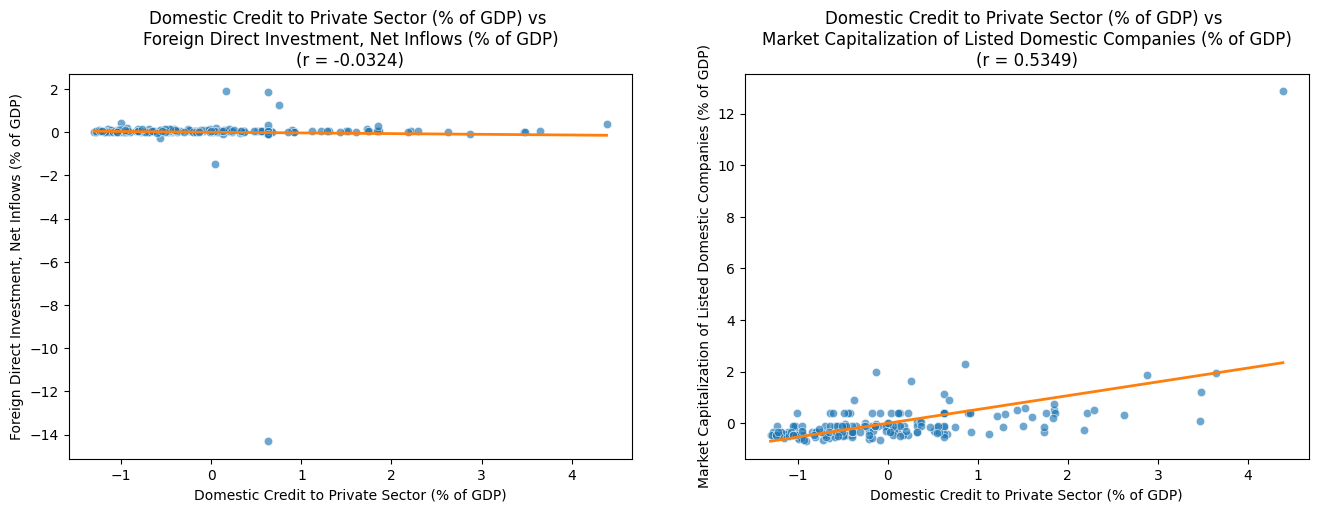

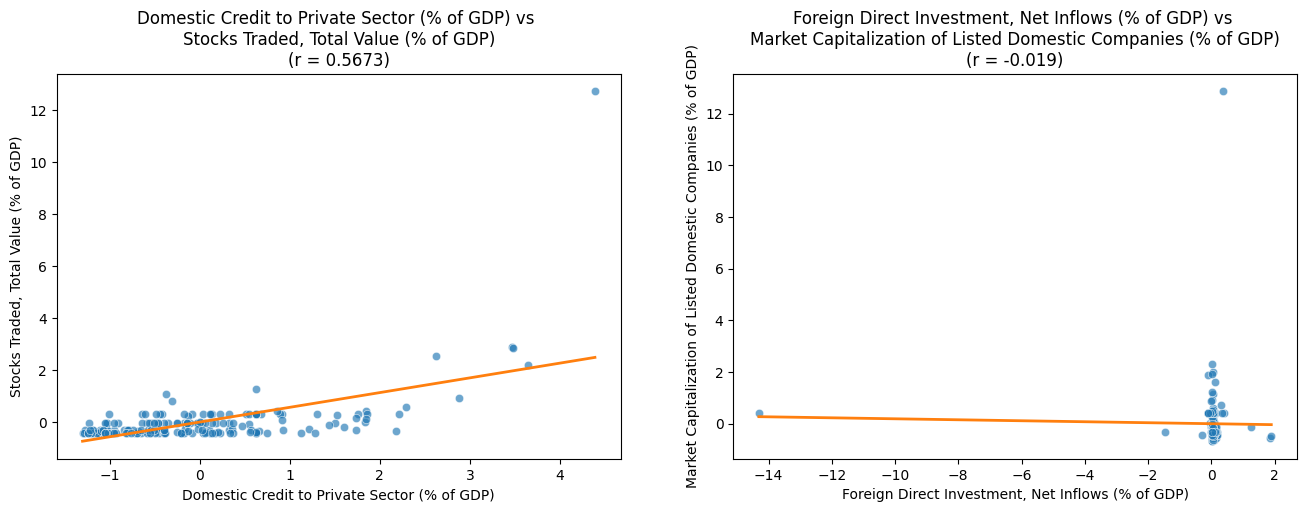

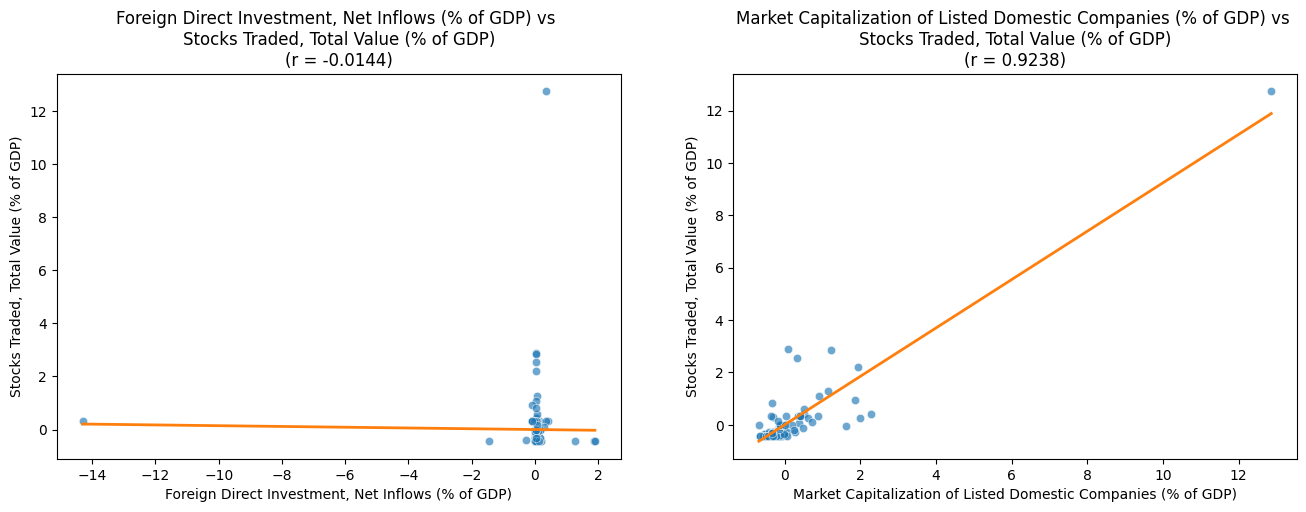


Sub-Index: Technology & Innovation
--------------------------------------------------


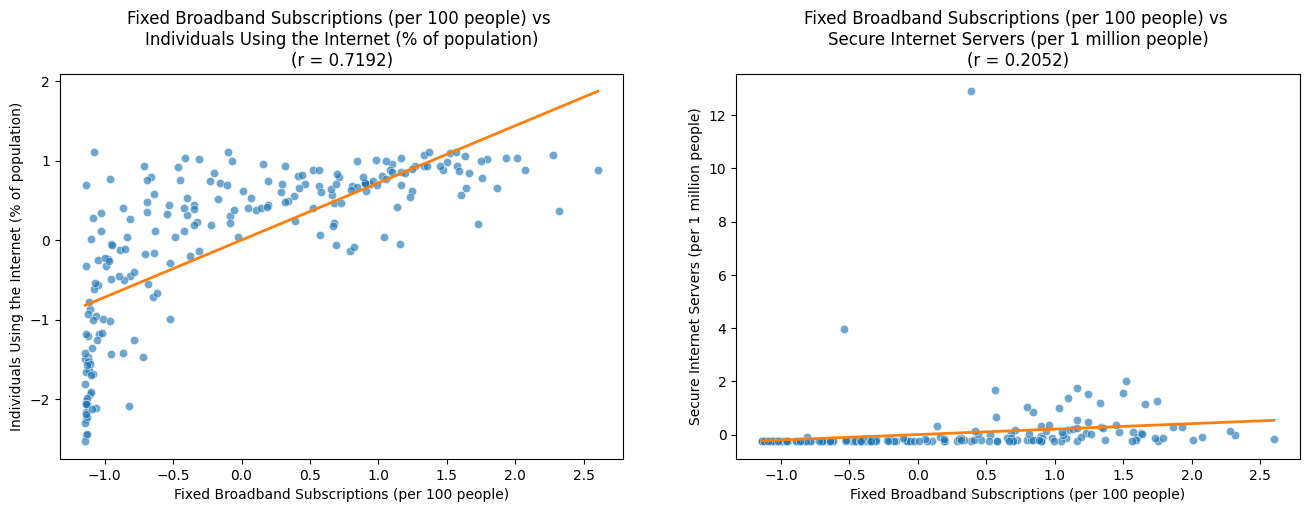

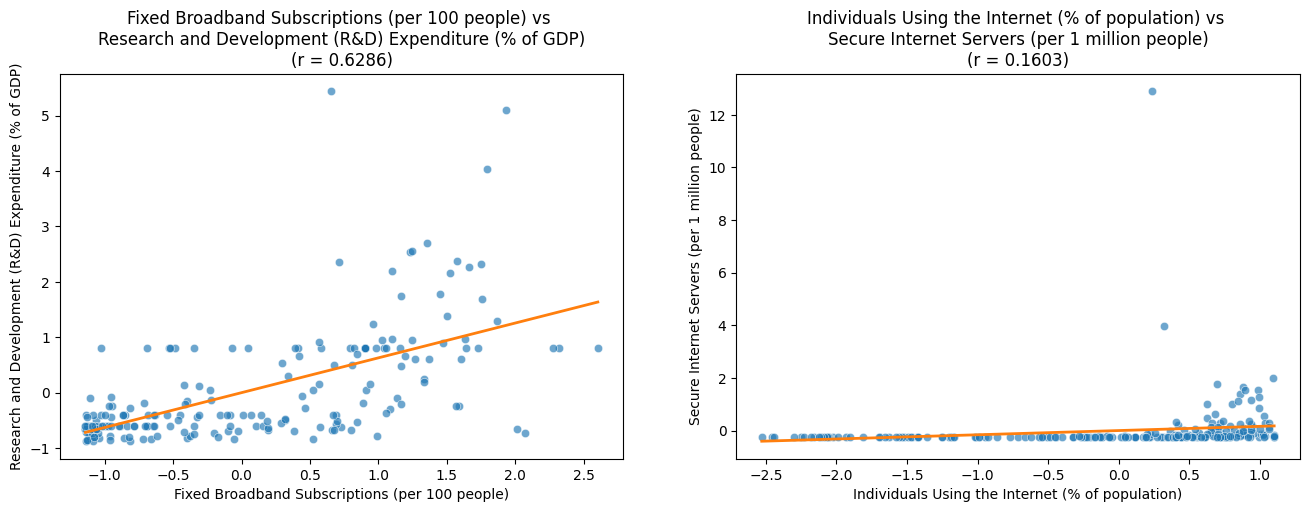

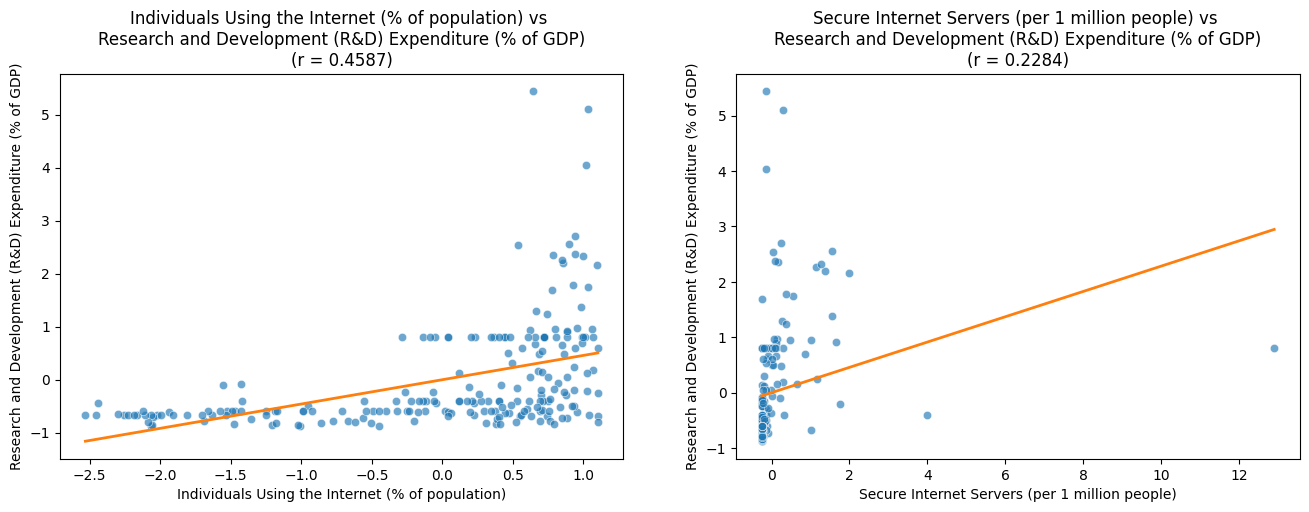


Sub-Index: Economic Growth & Stability
--------------------------------------------------


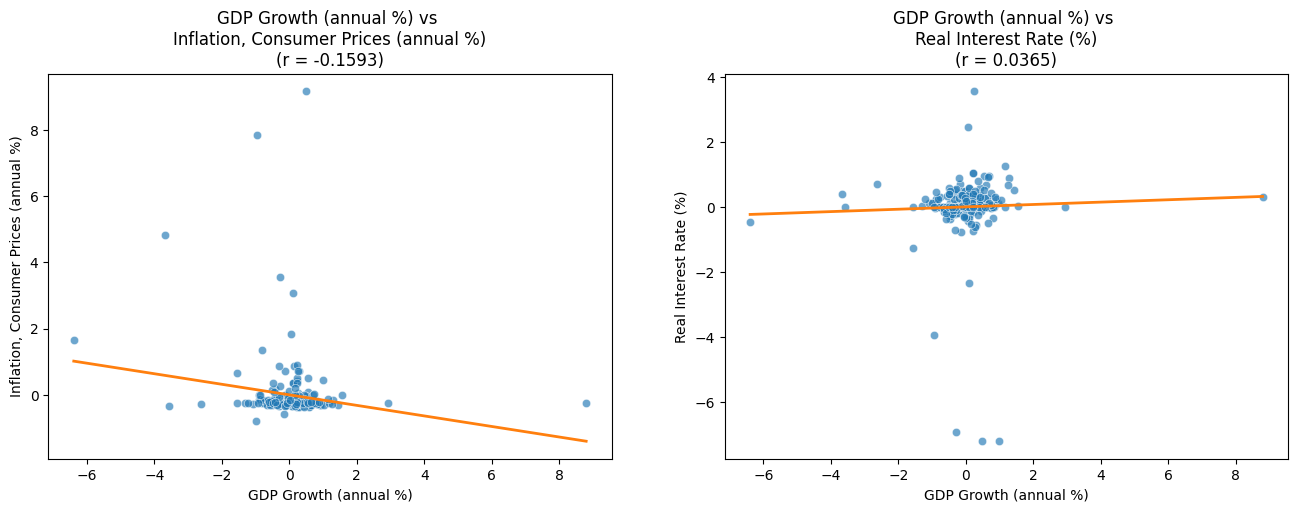

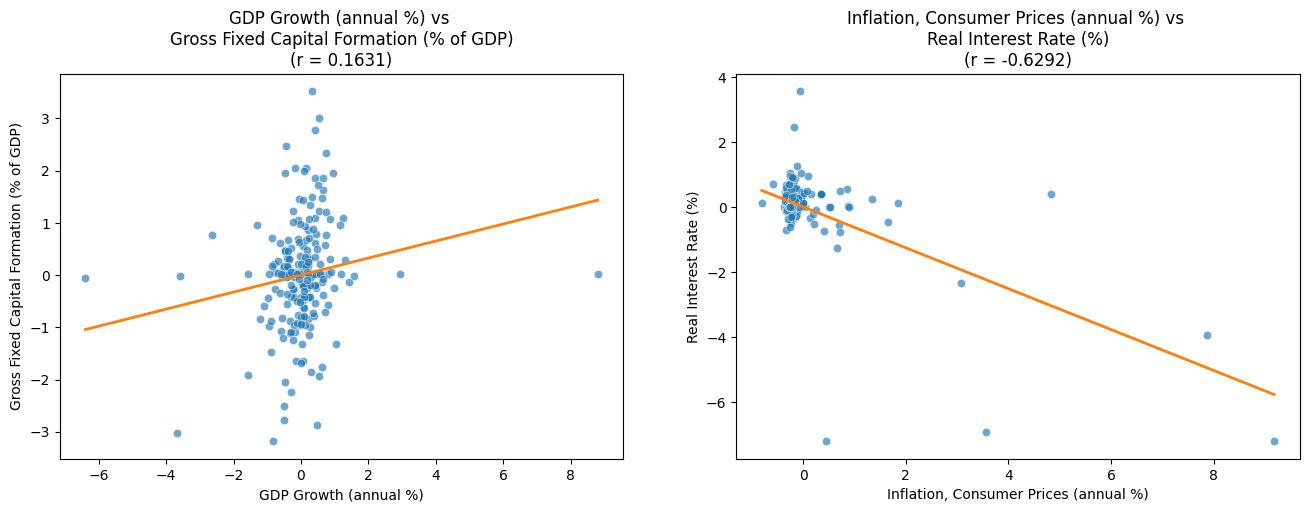

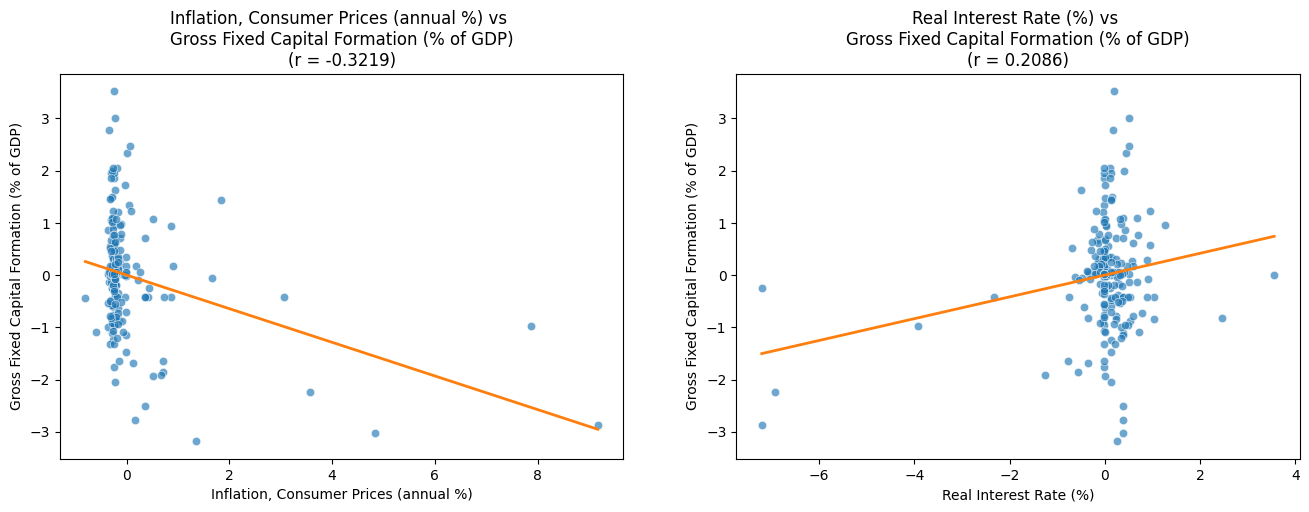


Sub-Index: Talent & Productivity
--------------------------------------------------


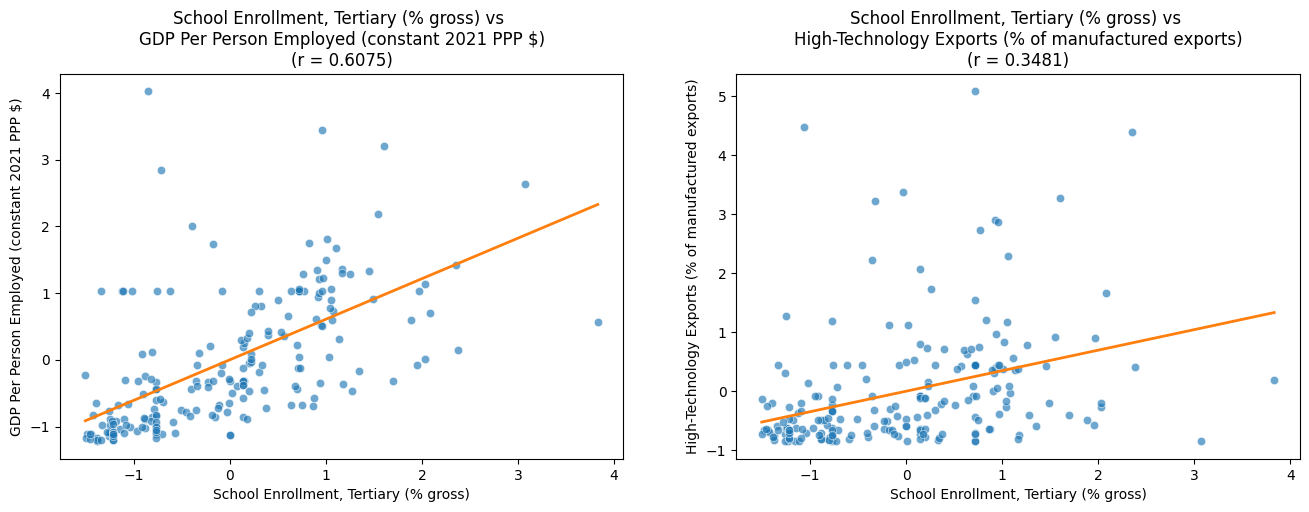

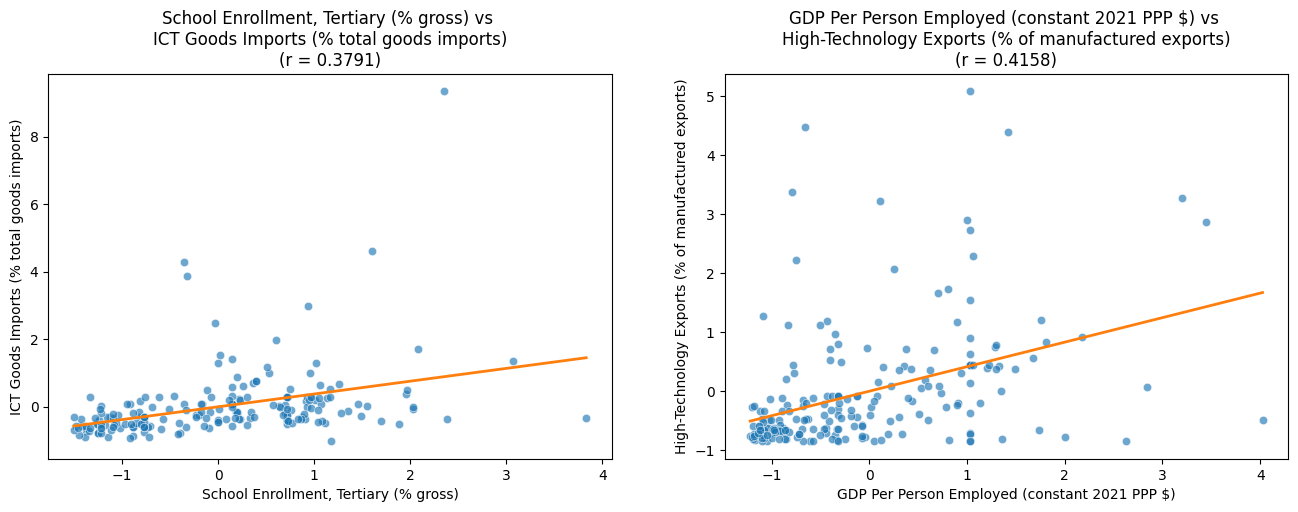

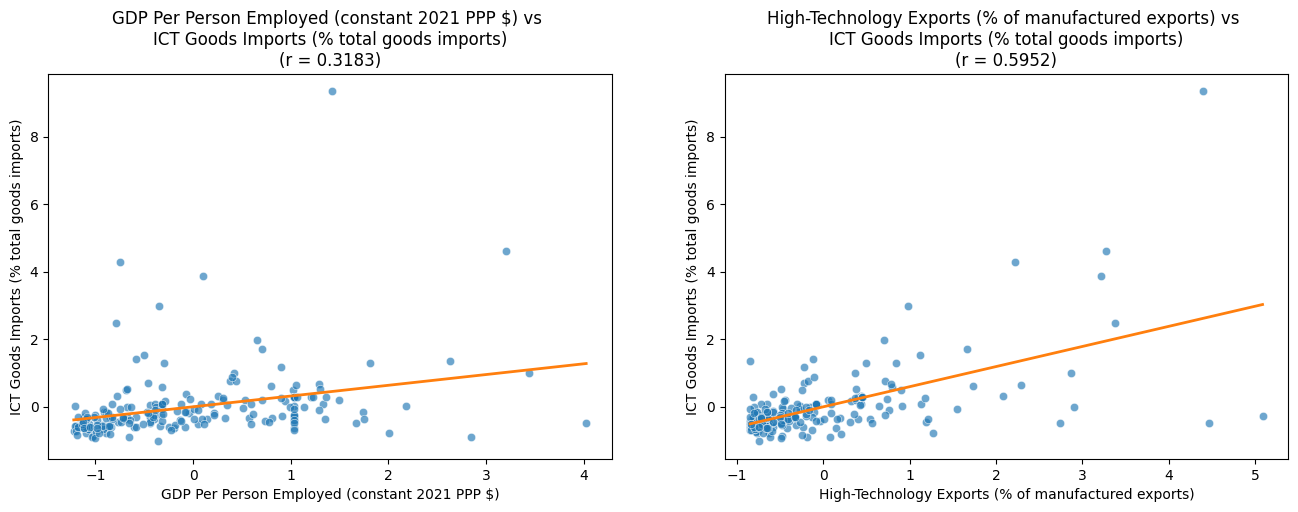

In [ ]:
if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found. Run Section 3 code first.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)

    # Select only numeric columns for scaling 
    exclude_cols = ['Country Name', 'Country Code', 'Income Group']
    numeric_cols = [col for col in df_snapshot.columns if col not in exclude_cols]

    # Standardize values using Z-score (makes variables comparable)
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(df_snapshot[numeric_cols])
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=numeric_cols,
        index=df_snapshot['Country Code']
    )

    # Readable names for each indicator
    indicator_labels = {
        "credit_to_private_sector": "Domestic Credit to Private Sector (% of GDP)",
        "fdi_inflows": "Foreign Direct Investment, Net Inflows (% of GDP)",
        "market_capitalisation": "Market Capitalization of Listed Domestic Companies (% of GDP)",
        "stock_market_liquidity": "Stocks Traded, Total Value (% of GDP)",
        "broadband_subscriptions": "Fixed Broadband Subscriptions (per 100 people)",
        "internet_usage_rate": "Individuals Using the Internet (% of population)",
        "secure_servers_density": "Secure Internet Servers (per 1 million people)",
        "rd_expenditure": "Research and Development (R&D) Expenditure (% of GDP)",
        "gdp_growth": "GDP Growth (annual %)",
        "inflation_rate": "Inflation, Consumer Prices (annual %)",
        "real_interest_rate": "Real Interest Rate (%)",
        "capital_formation": "Gross Fixed Capital Formation (% of GDP)",
        "tertiary_enrollment": "School Enrollment, Tertiary (% gross)",
        "labor_productivity": "GDP Per Person Employed (constant 2021 PPP $)",
        "high_tech_exports": "High-Technology Exports (% of manufactured exports)",
        "ict_imports": "ICT Goods Imports (% total goods imports)"
    }

    # Group variables into sub-indices
    sub_indices = {
        "Finance & Investment": [
            "credit_to_private_sector", "fdi_inflows",
            "market_capitalisation", "stock_market_liquidity"
        ],
        "Technology & Innovation": [
            "broadband_subscriptions", "internet_usage_rate",
            "secure_servers_density", "rd_expenditure"
        ],
        "Economic Growth & Stability": [
            "gdp_growth", "inflation_rate",
            "real_interest_rate", "capital_formation"
        ],
        "Talent & Productivity": [
            "tertiary_enrollment", "labor_productivity",
            "high_tech_exports", "ict_imports"
        ]
    }

    # Pairwise correlation plots within each sub-index
    for sub_name, codes in sub_indices.items():
        print(f"\nSub-Index: {sub_name}")
        print("-" * 50)

        # Get readable labels for this group
        labels = [indicator_labels[code] for code in codes]
        pairs = list(combinations(labels, 2))

        # Loop through all pairs, 2 plots per row
        for i in range(0, len(pairs), 2):
            fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 
            # fig.subplots_adjust(wspace=0.3, hspace=0.3) 

            for j, ax in enumerate(axes):
                if i + j >= len(pairs):
                    ax.axis("off")  
                    continue

                var1_label, var2_label = pairs[i + j]

                # Convert labels back to column names
                code1 = [k for k, v in indicator_labels.items() if v == var1_label][0]
                code2 = [k for k, v in indicator_labels.items() if v == var2_label][0]

                x_data = df_scaled[code1]
                y_data = df_scaled[code2]

                # Calculate correlation
                r_val = x_data.corr(y_data, method='pearson')

                # Scatter plot
                ax.scatter(
                    x_data,
                    y_data,
                    alpha=0.65,
                    color="#1f77b4",  # blue-ish
                    edgecolors="white",
                    linewidth=0.5
                )

                # Trend line (linear fit)
                unique_x = np.unique(x_data)
                trendline = np.poly1d(np.polyfit(x_data, y_data, 1))(unique_x)
                ax.plot(
                    unique_x,
                    trendline,
                    color="#ff7f0e", 
                    linewidth=2
                )

                # Wrap long titles into multiple lines
                title_text = f"{var1_label} vs \n{var2_label}\n(r = {round(r_val, 4)})"
                ax.set_title(title_text, fontsize=12)

                # Axis labels
                ax.set_xlabel(var1_label, fontsize=10)
                ax.set_ylabel(var2_label, fontsize=10)

            plt.show()

In [11]:
if not os.path.exists(imputed_data_path):
    print(f"[ERROR] '{imputed_data_path}' not found!")
else:
    df_snapshot = pd.read_csv(imputed_data_path)
    
    # Isolate numeric columns for scaling
    exclude_cols = ['Country Name', 'Country Code', 'Income Group']
    numeric_cols = [col for col in df_snapshot.columns if col not in exclude_cols]
    
    # Standardize Data (Z-score)
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(df_snapshot[numeric_cols])
    df_scaled = pd.DataFrame(scaled_values, columns=numeric_cols, index=df_snapshot['Country Code'])
    
    # Mappings
    indicator_labels = {
        "credit_to_private_sector": "Domestic Credit to Private Sector (% of GDP)",
        "fdi_inflows": "Foreign Direct Investment, Net Inflows (% of GDP)",
        "market_capitalisation": "Market Capitalization of Listed Domestic Companies (% of GDP)",
        "stock_market_liquidity": "Stocks Traded, Total Value (% of GDP)",
        "broadband_subscriptions": "Fixed Broadband Subscriptions (per 100 people)",
        "internet_usage_rate": "Individuals Using the Internet (% of population)",
        "secure_servers_density": "Secure Internet Servers (per 1 million people)",
        "rd_expenditure": "Research and Development (R&D) Expenditure (% of GDP)",
        "gdp_growth": "GDP Growth (annual %)",
        "inflation_rate": "Inflation, Consumer Prices (annual %)",
        "real_interest_rate": "Real Interest Rate (%)",
        "capital_formation": "Gross Fixed Capital Formation (% of GDP)",
        "tertiary_enrollment": "School Enrollment, Tertiary (% gross)",
        "labor_productivity": "GDP Per Person Employed (constant 2021 PPP $)",
        "high_tech_exports": "High-Technology Exports (% of manufactured exports)",
        "ict_imports": "ICT Goods Imports (% total goods imports)"
    }

    sub_indices = {
        "Finance & Investment": ["credit_to_private_sector", "fdi_inflows", "market_capitalisation", "stock_market_liquidity"],
        "Technology & Innovation": ["broadband_subscriptions", "internet_usage_rate", "secure_servers_density", "rd_expenditure"],
        "Economic Growth & Stability": ["gdp_growth", "inflation_rate", "real_interest_rate", "capital_formation"],
        "Talent & Productivity": ["tertiary_enrollment", "labor_productivity", "high_tech_exports", "ict_imports"]
    }

    print("======================================================================")
    print("                EXACT SUB-INDEX CORRELATION NUMBERS REPORT             ")
    print("======================================================================")

    for sub_name, codes in sub_indices.items():
        print(f"\n[{sub_name}]")
        labels = [indicator_labels[code] for code in codes]
        
        for var1_label, var2_label in combinations(labels, 2):
            # Reverse lookup keys
            code1 = [k for k, v in indicator_labels.items() if v == var1_label][0]
            code2 = [k for k, v in indicator_labels.items() if v == var2_label][0]
            
            x_data = df_scaled[code1]
            y_data = df_scaled[code2]
            
            # Calculate the exact Pearson r value
            r_val = x_data.corr(y_data, method='pearson')
            
            print(f"  * {var1_label} vs {var2_label}")
            
    print("======================================================================")

                EXACT SUB-INDEX CORRELATION NUMBERS REPORT             

[Finance & Investment]
  * Domestic Credit to Private Sector (% of GDP) vs Foreign Direct Investment, Net Inflows (% of GDP)
  * Domestic Credit to Private Sector (% of GDP) vs Market Capitalization of Listed Domestic Companies (% of GDP)
  * Domestic Credit to Private Sector (% of GDP) vs Stocks Traded, Total Value (% of GDP)
  * Foreign Direct Investment, Net Inflows (% of GDP) vs Market Capitalization of Listed Domestic Companies (% of GDP)
  * Foreign Direct Investment, Net Inflows (% of GDP) vs Stocks Traded, Total Value (% of GDP)
  * Market Capitalization of Listed Domestic Companies (% of GDP) vs Stocks Traded, Total Value (% of GDP)

[Technology & Innovation]
  * Fixed Broadband Subscriptions (per 100 people) vs Individuals Using the Internet (% of population)
  * Fixed Broadband Subscriptions (per 100 people) vs Secure Internet Servers (per 1 million people)
  * Fixed Broadband Subscriptions (per 100 peo